In [6]:
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [2]:
df = pd.read_csv('dailysales.csv')
df.head()

,date,sales
0,01-Jan-18,477.0
1,02-Jan-18,365.0
2,03-Jan-18,442.0
3,04-Jan-18,490.0
4,05-Jan-18,396.0


In [3]:
df.isnull().sum()

date     0
sales    0
dtype: int64

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 704 entries, 0 to 703
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    704 non-null    object 
 1   sales   704 non-null    float64
dtypes: float64(1), object(1)
memory usage: 11.1+ KB


In [7]:
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['dayofweek'] = df['date'].dt.dayofweek

print("Processed Dataset:")
print(df.head())

Processed Dataset:
        date  sales  year  month  day  dayofweek
0 2018-01-01  477.0  2018      1    1          0
1 2018-01-02  365.0  2018      1    2          1
2 2018-01-03  442.0  2018      1    3          2
3 2018-01-04  490.0  2018      1    4          3
4 2018-01-05  396.0  2018      1    5          4


C:\Users\KRISHNA SHARMA\AppData\Local\Temp\ipykernel_9824\2256424618.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['date'] = pd.to_datetime(df['date'])


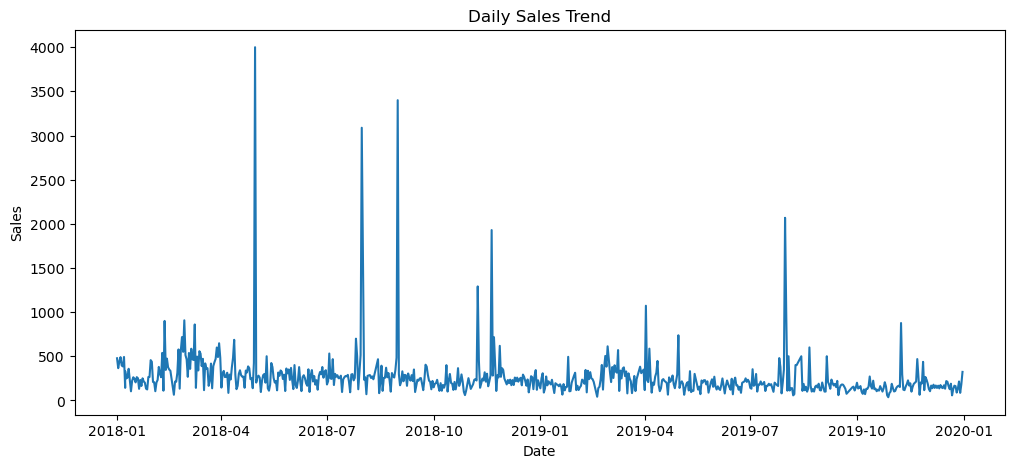

In [8]:
plt.figure(figsize=(12,5))
plt.plot(df['date'], df['sales'])
plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

In [9]:
monthly_sales = df.groupby('month')['sales'].mean()

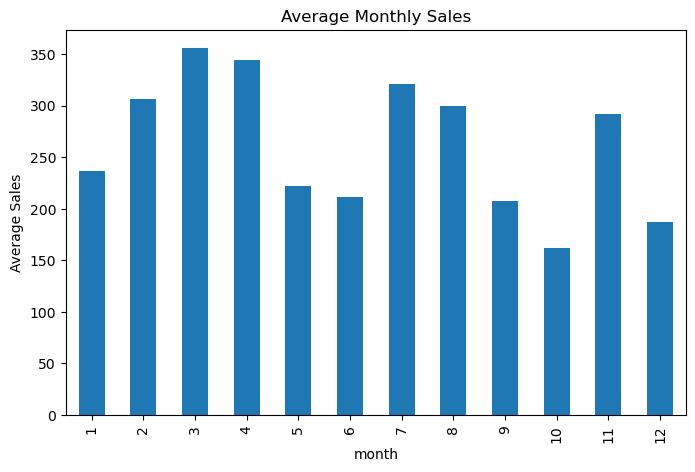

In [10]:
plt.figure(figsize=(8,5))
monthly_sales.plot(kind='bar')
plt.title("Average Monthly Sales")
plt.ylabel("Average Sales")
plt.show()

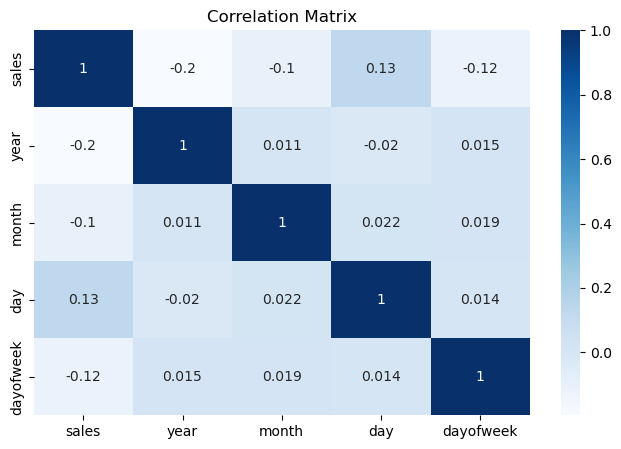

In [11]:
plt.figure(figsize=(8,5))
sns.heatmap(df[['sales','year','month','day','dayofweek']].corr(),
            annot=True,
            cmap='Blues')
plt.title("Correlation Matrix")
plt.show()

In [12]:
x = df[['year', 'month', 'day', 'dayofweek']]
y = df['sales']
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

model = LinearRegression()
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

In [15]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Model Evaluation")
print("-"*30)
print("MAE :", round(mae,2))
print("MSE :", round(mse,2))
print("RMSE:", round(rmse,2))
print("R² Score:", round(r2,2))

Model Evaluation
------------------------------
MAE : 116.47
MSE : 107567.32
RMSE: 327.97
R² Score: 0.09


In [17]:
results = pd.DataFrame({
    'Actual Sales': y_test,
    'Predicted Sales': y_pred
})

print("Sample Predictions:")
print(results.head())

Sample Predictions:
     Actual Sales  Predicted Sales
296         182.0       344.115139
81          137.0       325.526977
77          364.0       355.794822
208         323.0       306.622505
318         716.0       296.223316


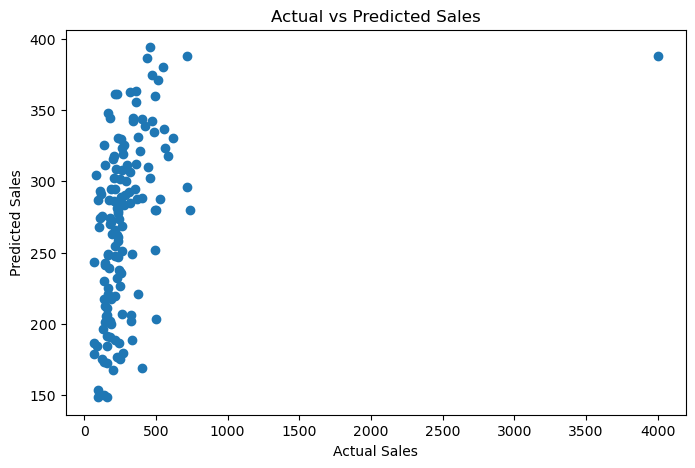

In [18]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.show()

In [21]:
future_dates = pd.date_range(start=df['date'].max() + pd.Timedelta(days=1),periods=30)

In [22]:
future_df = pd.DataFrame({
    'year': future_dates.year,
    'month': future_dates.month,
    'day': future_dates.day,
    'dayofweek': future_dates.dayofweek
})

In [23]:
future_predictions = model.predict(future_df)

forecast = pd.DataFrame({
    'Date': future_dates,
    'Forecasted Sales': future_predictions
})

print("Next 30 Days Forecast:")
print(forecast.head())

Next 30 Days Forecast:
        Date  Forecasted Sales
0 2020-01-01        109.280984
1 2020-01-02        101.714023
2 2020-01-03         94.147062
3 2020-01-04         86.580101
4 2020-01-05         79.013139


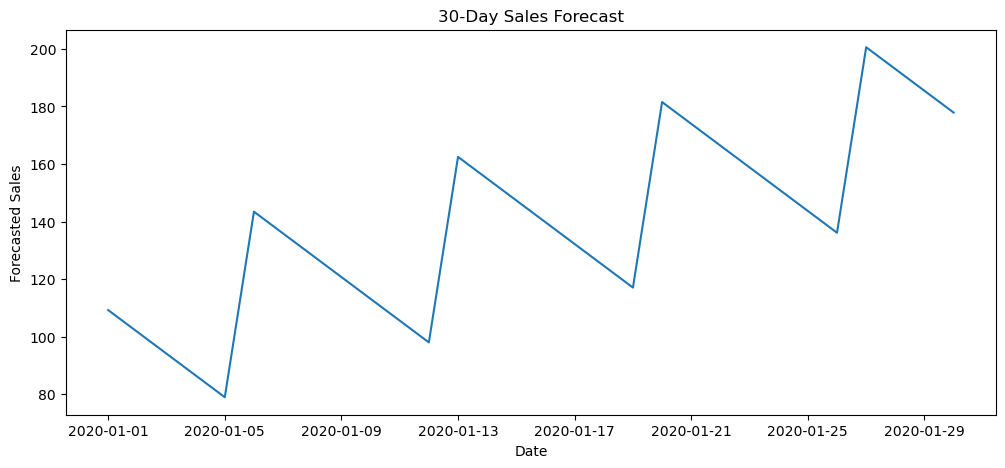

In [24]:
plt.figure(figsize=(12,5))
plt.plot(forecast['Date'],forecast['Forecasted Sales'])
plt.title("30-Day Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Forecasted Sales")
plt.show()